# Face Blurring for Privacy Protection

## Overview

This project implements a computer vision pipeline for automatically detecting human faces in images and applying a privacy-preserving blur to the detected regions.

The system uses OpenCV and a pre-trained Haar Cascade face detector to locate faces, followed by Gaussian blurring to anonymize the detected facial regions.

### Project Pipeline

The overall workflow is:

**Input Image → Preprocessing → Face Detection → Face Region Extraction → Face Blurring → Privacy-Protected Image**

### Objectives

- Detect human faces automatically in images.
- Apply a strong blur to detected faces.
- Support images containing multiple faces.
- Preserve the original image while generating a protected copy.
- Visualize the detection and anonymization results.
- Analyze the strengths and limitations of the approach.

### Technologies

- **Python**
- **OpenCV**
- **NumPy**
- **Matplotlib**

> **Note:** This project focuses on image-based face anonymization. The Haar Cascade detector is used as a classical computer vision baseline and its limitations are discussed later in the notebook.

In [1]:
# import dependencies
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

OpenCV version: 4.10.0
NumPy version: 2.4.6
Matplotlib version: 3.11.1


In [2]:
#configuration
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
INPUT_DIR = DATA_DIR / "input"
OUTPUT_DIR = DATA_DIR / "output"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: C:\Users\haaat
Input directory: C:\Users\haaat\data\input
Output directory: C:\Users\haaat\data\output


## Face Detection

Face detection is the first computer vision stage of the privacy pipeline.

This project uses OpenCV's pre-trained **Haar Cascade frontal-face classifier** as the baseline detector.

The classifier examines an image at multiple scales and returns bounding boxes around regions that are likely to contain faces.

Each detected face is represented by:

`(x, y, width, height)`

where `(x, y)` specifies the top-left corner of the detected region.

In [3]:
cascade_path = Path(
    cv2.data.haarcascades
) / "haarcascade_frontalface_default.xml"

face_cascade = cv2.CascadeClassifier(str(cascade_path))

if face_cascade.empty():
    raise RuntimeError(
        f"Failed to load Haar Cascade classifier from: {cascade_path}"
    )

print("Haar Cascade face detector loaded successfully.")

Haar Cascade face detector loaded successfully.


## Input Image

The system accepts an image provided by the user and performs face detection and anonymization on that image.

For reproducibility, input images are stored in the project's `data/input/` directory.

The pipeline first validates that the image exists and can be loaded successfully before any processing is performed.

In [4]:
# Find image in the input directory
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = [
    path for path in INPUT_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
]

if not image_files:
    raise FileNotFoundError(
        f"No supported image files found in: {INPUT_DIR}"
    )

image_path = image_files[0]

print(f"Selected image: {image_path.name}")

Selected image: istockphoto-1368965646-612x612.jpg


## Image Loading and Validation

Images are loaded using OpenCV's `imread()` function.

OpenCV returns images as NumPy arrays using the **BGR (Blue, Green, Red)** channel order.

Before continuing, the pipeline verifies that the image was successfully loaded.

In [5]:
image = cv2.imread(str(image_path))

if image is None:
    raise ValueError(
        f"OpenCV could not load the image: {image_path}"
    )

print("Image loaded successfully.")
print(f"Image shape: {image.shape}")

Image loaded successfully.
Image shape: (408, 612, 3)


Because OpenCV loads images in BGR format while Matplotlib expects RGB, the image is converted before visualization.

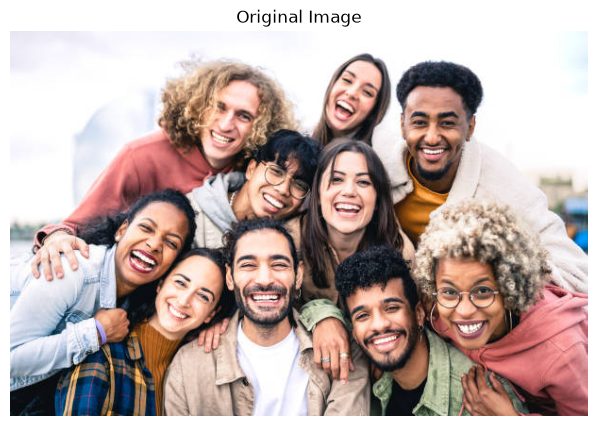

In [6]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Image Properties

Basic image properties are inspected before processing.

These values help verify that the input is valid and provide useful information when analyzing the behavior of the detection pipeline.

In [7]:
height, width = image.shape[:2]
channels = image.shape[2] if image.ndim == 3 else 1

print(f"Width: {width} pixels")
print(f"Height: {height} pixels")
print(f"Channels: {channels}")
print(f"Data type: {image.dtype}")

Width: 612 pixels
Height: 408 pixels
Channels: 3
Data type: uint8


## Image Preprocessing

The Haar Cascade face detector operates on grayscale images, so the color image is converted to grayscale before detection.

Two additional preprocessing operations are considered:

1. **Histogram equalization** — improves global image contrast.
2. **Gaussian smoothing** — reduces high-frequency noise that may interfere with detection.

The preprocessing stages are kept separate so that their effects can be visualized and evaluated.

In [8]:
# gray sclae
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print(f"Original shape: {image.shape}")
print(f"Grayscale shape: {gray_image.shape}")

Original shape: (408, 612, 3)
Grayscale shape: (408, 612)


### Grayscale Representation

The grayscale image contains intensity information rather than color information.

For face detection, this is sufficient because the Haar Cascade classifier relies primarily on patterns of brightness and contrast rather than color.

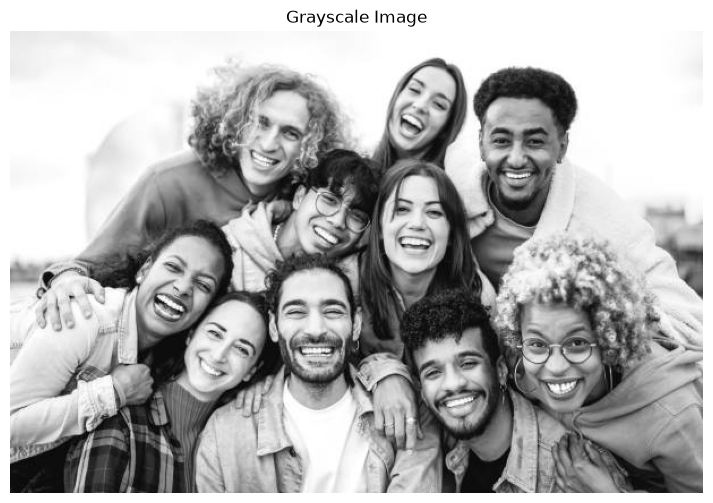

In [9]:
plt.figure(figsize=(10, 6))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

### Histogram Equalization

Histogram equalization redistributes pixel intensities to increase global contrast.

This can be useful when an image has poor lighting or a narrow range of intensity values.

However, increased contrast does not automatically mean better face detection. Therefore, the effect of equalization will be examined rather than assumed to improve the detector.

In [10]:
equalized_image = cv2.equalizeHist(gray_image)

print("Histogram equalization applied.")

Histogram equalization applied.


### Gaussian Smoothing

Gaussian smoothing reduces small-scale variations and high-frequency noise in the image.

A Gaussian kernel is applied to neighboring pixels, producing a smoother image.

For this project, a relatively small `5 × 5` kernel is used as an initial configuration.

The effect of smoothing will be evaluated because excessive smoothing can also remove useful facial features.

In [11]:
smoothed_image = cv2.GaussianBlur(
    equalized_image,
    (5, 5),
    0
)

print("Gaussian smoothing applied.")

Gaussian smoothing applied.


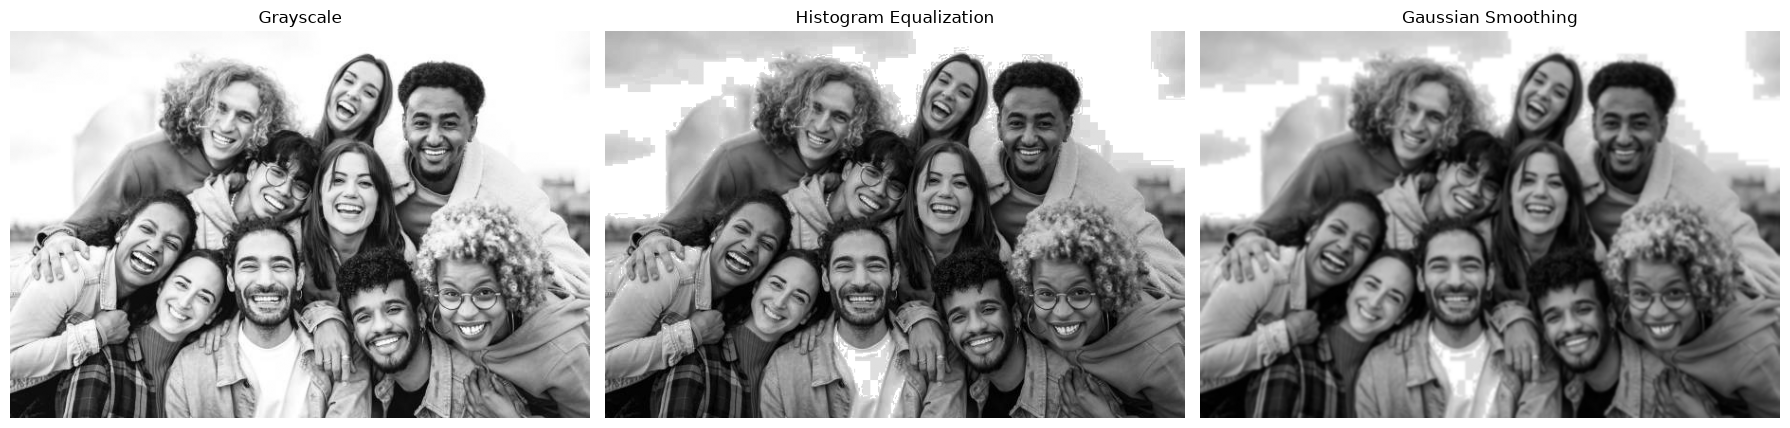

In [12]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(smoothed_image, cmap="gray")
plt.title("Gaussian Smoothing")
plt.axis("off")

plt.tight_layout()
plt.show()

### Preprocessing Pipeline

The individual preprocessing operations are now combined into a reusable function.

Keeping preprocessing in a function makes the pipeline easier to reuse, test, and modify later.

In [13]:
def preprocess_image(image):
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    equalized = cv2.equalizeHist(gray)
    smoothed = cv2.GaussianBlur(equalized, (5, 5), 0)

    return smoothed

In [14]:
processed_image = preprocess_image(image)

print(f"Processed image shape: {processed_image.shape}")

Processed image shape: (408, 612)


## Face Detection

The preprocessed image is passed to the Haar Cascade classifier to locate potential human faces.

The detector returns a bounding box for each detected face in the following format:

`(x, y, width, height)`

where:

- `x`, `y` — coordinates of the top-left corner of the bounding box
- `width` — width of the detected region
- `height` — height of the detected region

The detector parameters control the trade-off between detection sensitivity, false positives, and computational cost.

### Detection Parameters

The Haar Cascade detector uses several parameters to control its search.

- **`scaleFactor`** controls how much the image is reduced between detection scales. Smaller values perform a more thorough multi-scale search but require more computation.
- **`minNeighbors`** controls how many neighboring candidate detections are required before a region is accepted as a face. Higher values generally make the detector more conservative.
- **`minSize`** specifies the minimum size of a detected face.

The initial values below are baseline settings rather than guaranteed optimal values. They can be tuned later using an evaluation dataset.

In [15]:
def detect_faces(
    image,
    scale_factor=1.1,
    min_neighbors=5,
    min_size=(30, 30)
):
    """
    Detect faces in a grayscale image using Haar Cascade.

    Parameters
    ----------
    image : np.ndarray
        Grayscale image to analyze.

    scale_factor : float
        Scale reduction between successive detection stages.

    min_neighbors : int
        Minimum number of neighboring detections required
        for a region to be considered a face.

    min_size : tuple
        Minimum possible face size in pixels.

    Returns
    -------
    np.ndarray
        Detected face bounding boxes in the format
        (x, y, width, height).
    """
    faces = face_cascade.detectMultiScale(
        image,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
    )

    return faces

In [16]:
faces = detect_faces(processed_image)

print(f"Number of faces detected: {len(faces)}")

Number of faces detected: 7


### Detection Result

The detector returns one bounding box for each detected face.

The number of detected faces is reported before visualization so that the result can also be evaluated programmatically.

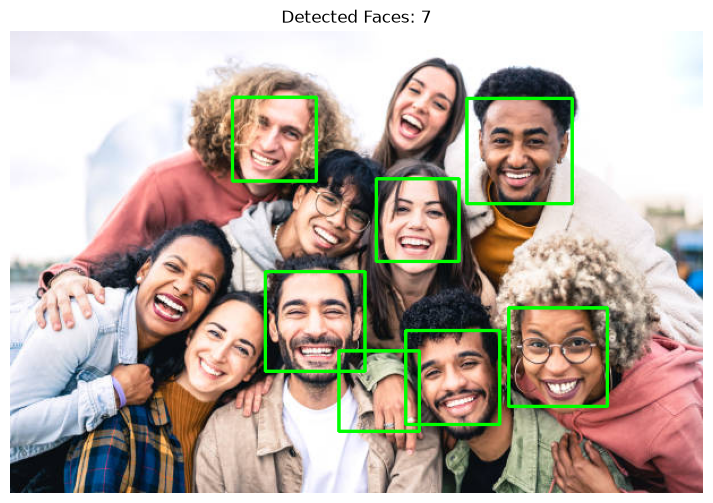

In [17]:
detection_image = image.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(
        detection_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

detection_image_rgb = cv2.cvtColor(
    detection_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 6))
plt.imshow(detection_image_rgb)
plt.title(f"Detected Faces: {len(faces)}")
plt.axis("off")
plt.show()

### Detection Performance Observation

In a test image containing **10 faces**, the detector correctly identified **6 faces**, while **4 faces were missed**. One additional region, corresponding to a hand, was incorrectly classified as a face, resulting in a **false positive**.

The missed faces were primarily positioned at approximately a **45° sideways angle**, which highlights a limitation of the Haar Cascade frontal-face detector. The classifier is designed primarily for frontal faces and can therefore perform poorly when faces are rotated or viewed from the side.

The detection parameters, including `scaleFactor`, `minNeighbors`, and `minSize`, can be tuned later to improve the balance between **detecting more faces and reducing false positives**. However, parameter tuning alone may not fully solve the limitations associated with rotated faces, which will be discussed in the evaluation section.



### Handling Images Without Detected Faces

A privacy pipeline should not assume that every image contains a face.

If no faces are detected, the original image should remain unchanged and the system should report that no anonymization was necessary.

This behavior is important for making the pipeline robust when processing arbitrary images.

In [18]:
if len(faces) == 0:
    print("No faces were detected.")
else:
    print(f"{len(faces)} face(s) detected.")

7 face(s) detected.


## Face Anonymization

Once faces have been detected, the corresponding facial regions are anonymized to reduce the possibility of identifying the individuals in the image.

This project initially uses **Gaussian blurring** as the anonymization method.

The original image is not modified directly. Instead, a copy is created and the blur is applied to that copy.

This allows the original and privacy-protected images to be compared side by side.

### Gaussian Blur

Gaussian blur replaces each pixel with a weighted average of surrounding pixels.

For privacy protection, a sufficiently strong blur removes facial details such as fine edges and local features while preserving the overall structure of the image.

The strength of the blur depends primarily on:

- **Kernel size** — controls the spatial extent of the blur.
- **Sigma** — controls the spread of the Gaussian function.

The initial configuration uses a large kernel because the objective is anonymization rather than simple visual smoothing.

In [19]:
def blur_faces(
    image,
    faces,
    kernel_size=(99, 99),
    sigma=30
):
    """
    Blur detected face regions in an image.

    Parameters
    ----------
    image : np.ndarray
        Input BGR image.

    faces : np.ndarray
        Face bounding boxes in the format
        (x, y, width, height).

    kernel_size : tuple
        Gaussian blur kernel size.

    sigma : float
        Gaussian standard deviation.

    Returns
    -------
    np.ndarray
        Copy of the image with detected faces blurred.
    """
    result = image.copy()

    for (x, y, w, h) in faces:
        face_region = result[y:y+h, x:x+w]

        blurred_region = cv2.GaussianBlur(
            face_region,
            kernel_size,
            sigma
        )

        result[y:y+h, x:x+w] = blurred_region

    return result

In [20]:
blurred_image = blur_faces(
    image,
    faces
)

print("Face anonymization completed.")

Face anonymization completed.


## Privacy Protection Result

The original image and anonymized image are displayed together to verify that:

1. The detected facial regions were modified.
2. The rest of the image remains unchanged.
3. Multiple detected faces are anonymized when present.

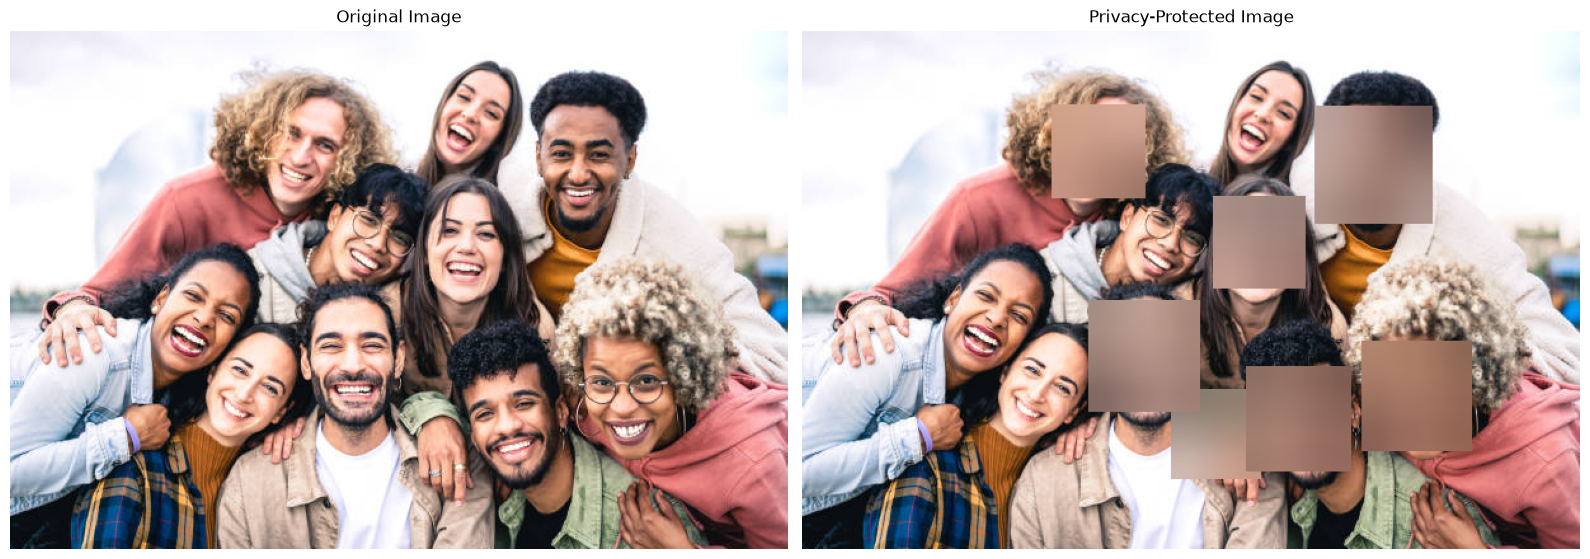

In [21]:
blurred_image_rgb = cv2.cvtColor(
    blurred_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_image_rgb)
plt.title("Privacy-Protected Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
print("Anonymization Summary")
print("-" * 30)
print(f"Detected faces: {len(faces)}")
print(f"Blur kernel: {99} × {99}")
print(f"Gaussian sigma: {30}")

Anonymization Summary
------------------------------
Detected faces: 7
Blur kernel: 99 × 99
Gaussian sigma: 30


## End-to-End Face Anonymization Pipeline

The previous sections implemented and tested each stage of the pipeline independently.

We can now combine these stages into a single reusable function.

The complete workflow is:

**Input Image → Preprocessing → Face Detection → Face Blurring → Protected Image**

This makes the system easier to reuse for multiple images and provides a foundation for later batch processing.

In [23]:
def anonymize_image(
    image,
    scale_factor=1.1,
    min_neighbors=5,
    min_size=(30, 30),
    blur_kernel=(99, 99),
    blur_sigma=30
):
    """
    Detect and anonymize faces in an image.

    Parameters
    ----------
    image : np.ndarray
        Input BGR image.

    scale_factor : float
        Scale reduction between Haar Cascade detection stages.

    min_neighbors : int
        Minimum number of neighboring detections required
        for a region to be considered a face.

    min_size : tuple
        Minimum possible face size.

    blur_kernel : tuple
        Gaussian blur kernel size.

    blur_sigma : float
        Gaussian blur standard deviation.

    Returns
    -------
    protected_image : np.ndarray
        Copy of the input image with detected faces blurred.

    faces : np.ndarray
        Detected face bounding boxes.
    """

    # Step 1: Preprocess image
    processed = preprocess_image(image)

    # Step 2: Detect faces
    faces = detect_faces(
        processed,
        scale_factor=scale_factor,
        min_neighbors=min_neighbors,
        min_size=min_size
    )

    # Step 3: Blur detected faces
    protected_image = blur_faces(
        image,
        faces,
        kernel_size=blur_kernel,
        sigma=blur_sigma
    )

    return protected_image, faces


The complete pipeline can now be executed with a single function call.

The returned values contain:

- the privacy-protected image
- the detected face bounding boxes

In [24]:
protected_image, detected_faces = anonymize_image(image)

print("Pipeline completed successfully.")
print(f"Faces detected: {len(detected_faces)}")

Pipeline completed successfully.
Faces detected: 7


## Visualizing the End-to-End Result

The final result is compared with the original image.

This visualization provides a quick qualitative check of the complete pipeline.

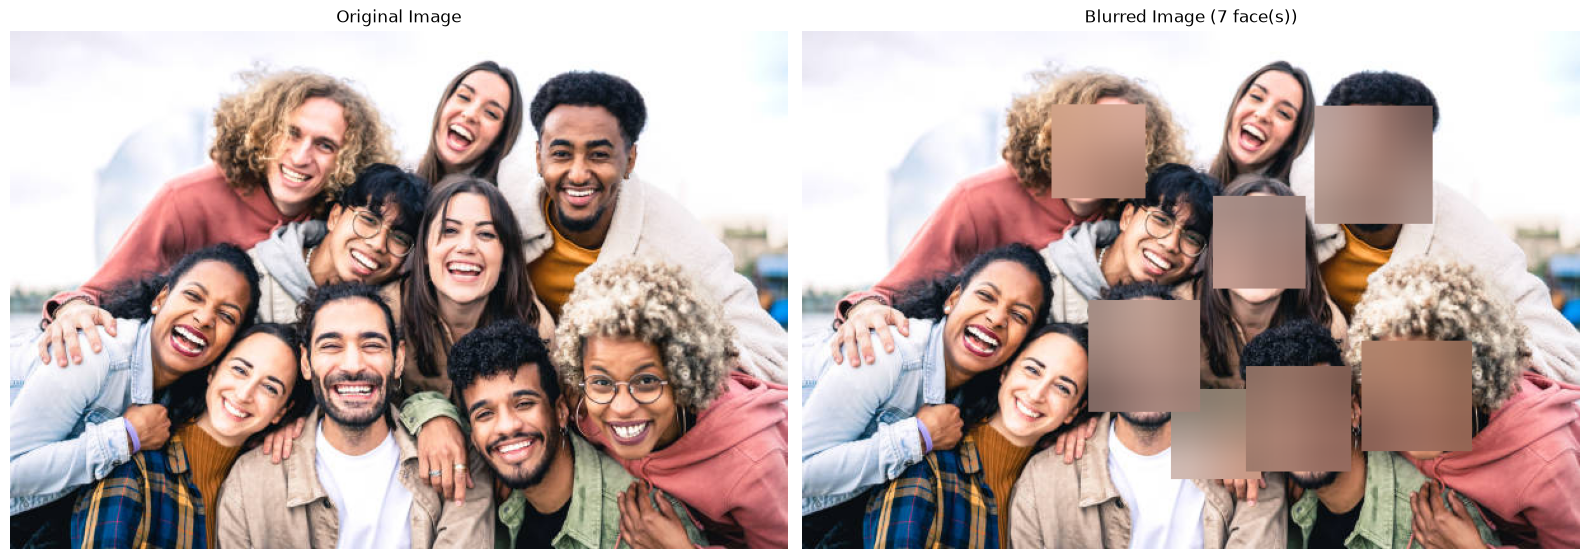

In [25]:
protected_image_rgb = cv2.cvtColor(
    protected_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(protected_image_rgb)
plt.title(f"Blurred Image ({len(detected_faces)} face(s))")
plt.axis("off")

plt.tight_layout()
plt.show()

## Saving the Protected Image

A practical privacy pipeline should produce an output file that can be used by another application or delivered to a client.

The protected image is therefore saved separately from the original input.

The original image remains untouched in the input directory.

In [26]:
output_path = OUTPUT_DIR / f"{image_path.stem}_protected{image_path.suffix}"

success = cv2.imwrite(
    str(output_path),
    protected_image
)

if not success:
    raise IOError(
        f"Failed to save protected image to: {output_path}"
    )

print(f"Protected image saved to: {output_path}")

Protected image saved to: C:\Users\haaat\data\output\istockphoto-1368965646-612x612_protected.jpg
